In [41]:
import pandas as pd
import matplotlib.pyplot as plt

target_steps = [8, 16, 32, 64, 128, 256, 512, 1024, 2048, 4096, 8192]
seeds = [0,2]

df = pd.read_csv('results/traffic_regression_seed_walk_sweep_20260309_115637.csv')

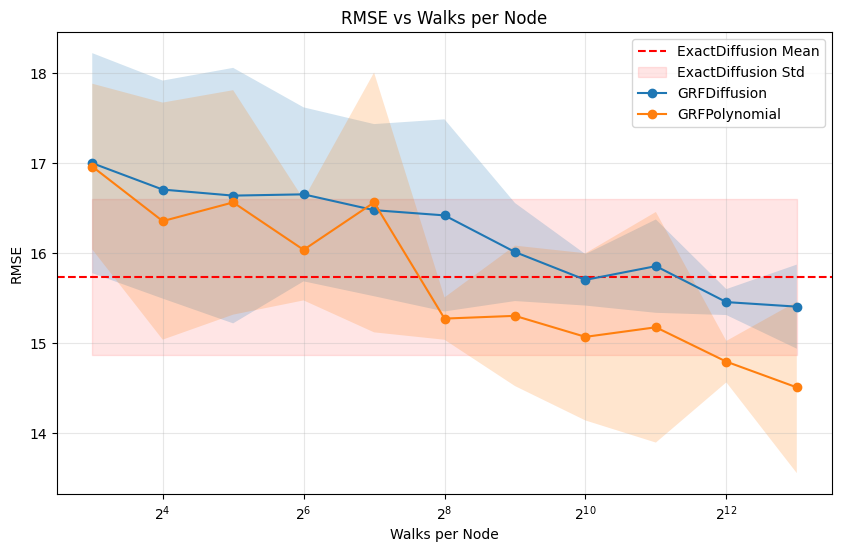

In [45]:
# 1. Process Baseline (ExactDiffusion) across all seeds
baseline_data = df[df['model'] == 'ExactDiffusion']['rmse']
b_mean, b_std = baseline_data.mean(), baseline_data.std()

# 2. Filter GRF models by the target_steps list
grf_filtered = df[(df['model'] != 'ExactDiffusion') & 
                  (df['walks_per_node'].isin(target_steps)) &
                  (df['seed'].isin(seeds))].copy()

# 3. Grouping for Plotting
stats = grf_filtered.groupby(['model', 'walks_per_node'])['rmse'].agg(['mean', 'std']).reset_index()

# 4. Plotting
plt.figure(figsize=(10, 6))

# Plot Baseline with Shading
plt.axhline(y=b_mean, color='red', linestyle='--', label='ExactDiffusion Mean')
plt.fill_between([min(target_steps), max(target_steps)], 
                 b_mean - b_std, b_mean + b_std, color='red', alpha=0.1, label='ExactDiffusion Std')

# Plot Approximation Models
for model in stats['model'].unique():
    m_data = stats[stats['model'] == model]
    plt.plot(m_data['walks_per_node'], m_data['mean'], marker='o', label=model)
    plt.fill_between(m_data['walks_per_node'], 
                     m_data['mean'] - m_data['std'], 
                     m_data['mean'] + m_data['std'], alpha=0.2)

plt.xscale('log', base=2)
plt.xlabel('Walks per Node')
plt.ylabel('RMSE')
plt.title('RMSE vs Walks per Node')
plt.legend()
plt.grid(True, which="both", ls="-", alpha=0.3)
plt.show()

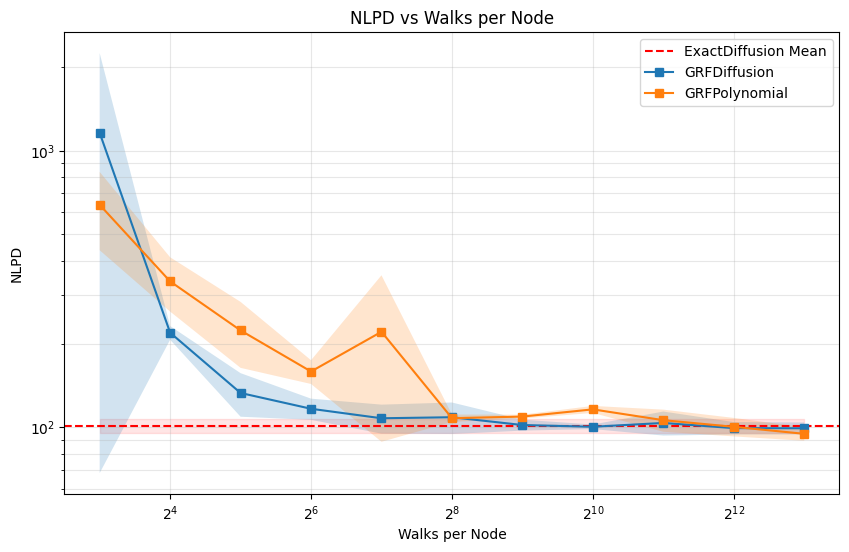

In [46]:
# 1. Process Baseline (ExactDiffusion) NLPD
baseline_nlpd = df[df['model'] == 'ExactDiffusion']['nlpd']
bn_mean, bn_std = baseline_nlpd.mean(), baseline_nlpd.std()

# 2. Filter and Group
stats_nlpd = grf_filtered.groupby(['model', 'walks_per_node'])['nlpd'].agg(['mean', 'std']).reset_index()

# 3. Plotting
plt.figure(figsize=(10, 6))

# Plot Baseline with Shading
plt.axhline(y=bn_mean, color='red', linestyle='--', label='ExactDiffusion Mean')
plt.fill_between([min(target_steps), max(target_steps)], 
                 bn_mean - bn_std, bn_mean + bn_std, color='red', alpha=0.1)

# Plot Approximation Models
for model in stats_nlpd['model'].unique():
    m_data = stats_nlpd[stats_nlpd['model'] == model]
    plt.plot(m_data['walks_per_node'], m_data['mean'], marker='s', label=model)
    plt.fill_between(m_data['walks_per_node'], 
                     m_data['mean'] - m_data['std'], 
                     m_data['mean'] + m_data['std'], alpha=0.2)

plt.xscale('log', base=2)
plt.yscale('log')
plt.xlabel('Walks per Node')
plt.ylabel('NLPD')
plt.title('NLPD vs Walks per Node')
plt.legend()
plt.grid(True, which="both", ls="-", alpha=0.3)
plt.show()